## Задача 2. Линейная регрессия, метод градиентного спуска
Ноутбук адаптирован под локальный `car_price.csv` без переименования столбцов.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

In [3]:
df = pd.read_csv('car_price.csv')
print('Исходные столбцы:', df.columns.tolist())

# Удаляем идентификатор и название модели (неинформативные для линейной регрессии)
if 'car_ID' in df.columns:
    df.drop('car_ID', axis=1, inplace=True)
if 'CarName' in df.columns:
    df.drop('CarName', axis=1, inplace=True)

print('Размер данных:', df.shape)
df.head()

Исходные столбцы: ['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']
Размер данных: (205, 24)


,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### Очистка данных

In [4]:
# Удаляем строки, где нет цены
df.dropna(subset=['price'], inplace=True)

# Числовые столбцы, которые нужно проверить и заполнить медианой
num_cols = ['boreratio', 'stroke', 'horsepower', 'peakrpm', 'price']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Заполняем пропуски в категориальной колонке 'doornumber'
if 'doornumber' in df.columns and df['doornumber'].isnull().any():
    df['doornumber'] = df['doornumber'].fillna(df['doornumber'].mode()[0])

print('Пропусков после очистки:', df.isnull().sum().sum())

Пропусков после очистки: 0


### Разведочный анализ данных (EDA)

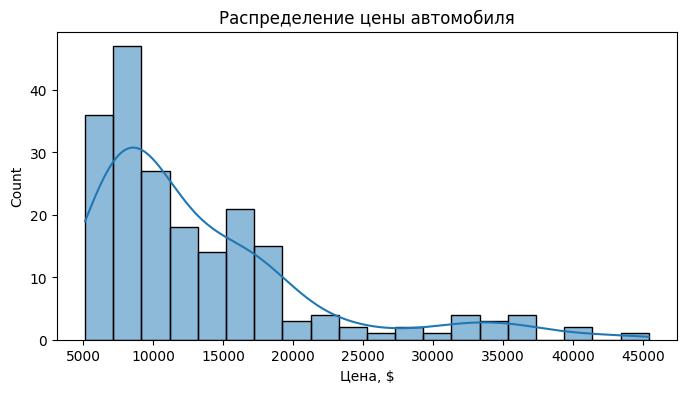

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=20, kde=True)
plt.title('Распределение цены автомобиля')
plt.xlabel('Цена, $')
plt.show()

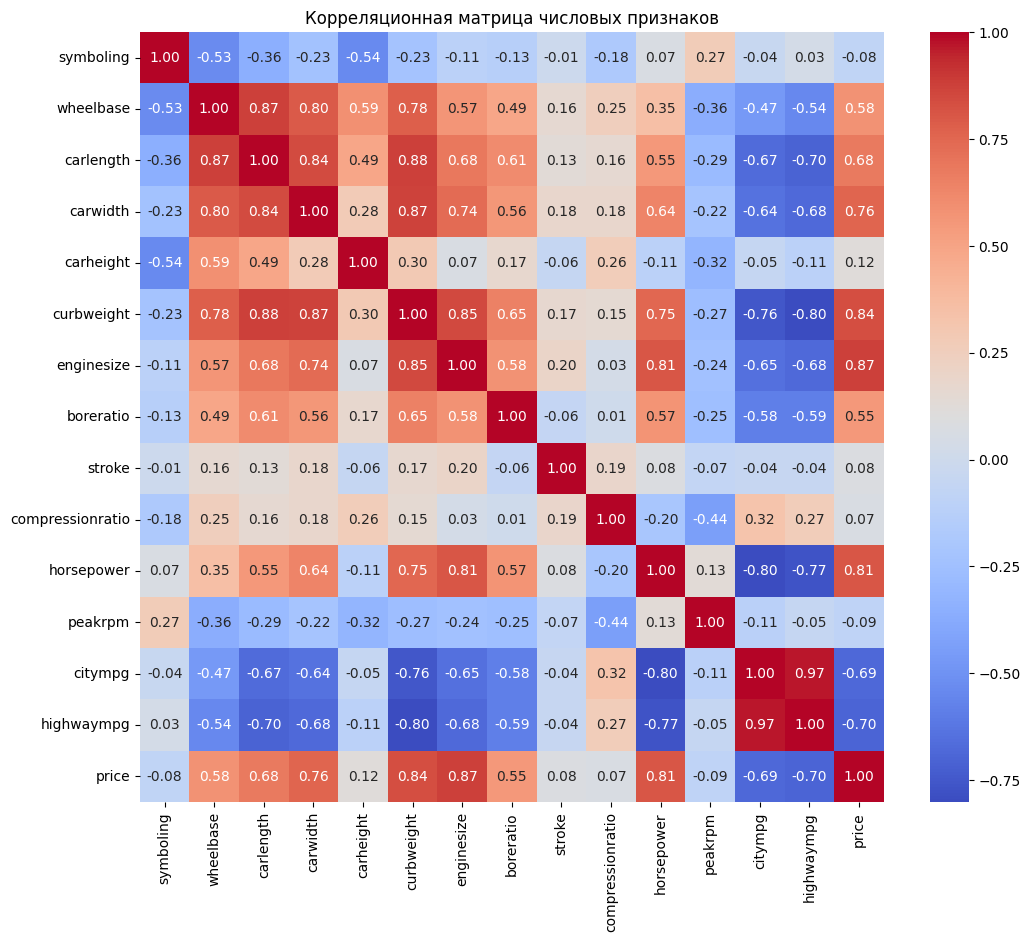

In [6]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляционная матрица числовых признаков')
plt.show()

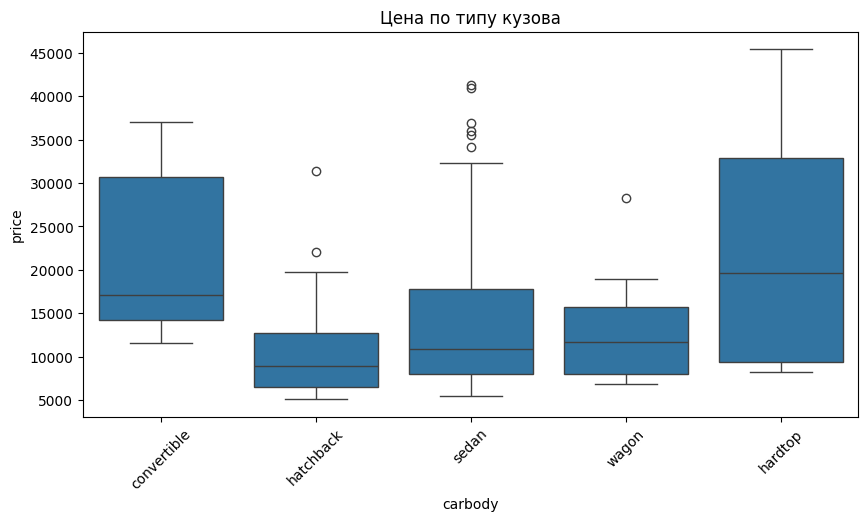

In [7]:
plt.figure(figsize=(10,5))
sns.boxplot(x='carbody', y='price', data=df)
plt.title('Цена по типу кузова')
plt.xticks(rotation=45)
plt.show()

### Feature Engineering

In [8]:
X = df.drop('price', axis=1)
y = df['price'].values

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

X_num = X[numeric_cols]
X_cat = X[categorical_cols]

encoder = OneHotEncoder(sparse_output=False, drop='first')
X_cat_encoded = encoder.fit_transform(X_cat)
cat_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()

X_processed = np.hstack([X_num.values, X_cat_encoded])
all_feature_names = numeric_cols + cat_feature_names
print(f'Число признаков после кодирования: {X_processed.shape[1]}')

Число признаков после кодирования: 43


### Разбиение на train/test и масштабирование

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Размеры: train', X_train_scaled.shape, 'test', X_test_scaled.shape)

Размеры: train (164, 43) test (41, 43)


### Реализация Batch Gradient Descent с L2-регуляризатором

In [10]:
def gradient_descent(X, y, lr=0.01, n_iter=1000, alpha=1.0):
    m, n = X.shape
    w = np.zeros(n)
    for i in range(n_iter):
        y_pred = X.dot(w)
        error = y_pred - y
        grad = (1/m) * X.T.dot(error) + alpha * w
        w -= lr * grad
    return w, []

def evaluate_model(w, X, y):
    y_pred = X.dot(w)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)
    return mse, rmse, r2

In [11]:
w_gd, _ = gradient_descent(X_train_scaled, y_train, lr=0.1, n_iter=5000, alpha=1.0)
mse_train_gd, rmse_train_gd, r2_train_gd = evaluate_model(w_gd, X_train_scaled, y_train)
mse_test_gd, rmse_test_gd, r2_test_gd = evaluate_model(w_gd, X_test_scaled, y_test)
print('GD (Batch) результаты:')
print(f'Train - MSE: {mse_train_gd:.2f}, RMSE: {rmse_train_gd:.2f}, R2: {r2_train_gd:.4f}')
print(f'Test  - MSE: {mse_test_gd:.2f}, RMSE: {rmse_test_gd:.2f}, R2: {r2_test_gd:.4f}')

GD (Batch) результаты:
Train - MSE: 183494696.25, RMSE: 13546.02, R2: -2.0768
Test  - MSE: 201717896.38, RMSE: 14202.74, R2: -1.5552


### Сравнение с Ridge (sklearn)

In [12]:
ridge = Ridge(alpha=1.0, fit_intercept=False)
ridge.fit(X_train_scaled, y_train)
y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)
mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
rmse_train_ridge = np.sqrt(mse_train_ridge)
r2_train_ridge = r2_score(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
rmse_test_ridge = np.sqrt(mse_test_ridge)
r2_test_ridge = r2_score(y_test, y_test_pred_ridge)
print('Ridge результаты:')
print(f'Train - MSE: {mse_train_ridge:.2f}, RMSE: {rmse_train_ridge:.2f}, R2: {r2_train_ridge:.4f}')
print(f'Test  - MSE: {mse_test_ridge:.2f}, RMSE: {rmse_test_ridge:.2f}, R2: {r2_test_ridge:.4f}')

Ridge результаты:
Train - MSE: 178019456.71, RMSE: 13342.39, R2: -1.9850
Test  - MSE: 189915791.75, RMSE: 13780.99, R2: -1.4057


### Кросс-валидация (5 фолдов) для Batch GD

In [13]:
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_metrics = []
for train_idx, val_idx in kf.split(X_processed):
    X_tr, X_val = X_processed[train_idx], X_processed[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    scaler_cv = StandardScaler()
    X_tr_sc = scaler_cv.fit_transform(X_tr)
    X_val_sc = scaler_cv.transform(X_val)
    w_cv, _ = gradient_descent(X_tr_sc, y_tr, lr=0.1, n_iter=5000, alpha=1.0)
    mse_tr, rmse_tr, r2_tr = evaluate_model(w_cv, X_tr_sc, y_tr)
    mse_val, rmse_val, r2_val = evaluate_model(w_cv, X_val_sc, y_val)
    fold_metrics.append([mse_tr, mse_val, rmse_tr, rmse_val, r2_tr, r2_val])

cols = ['MSE_train', 'MSE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test']
fold_df = pd.DataFrame(fold_metrics, columns=cols, index=[f'Fold{i+1}' for i in range(k)])
mean_row = fold_df.mean()
std_row = fold_df.std()
summary_df = pd.DataFrame([mean_row, std_row], index=['E (среднее)', 'STD'])
result_df = pd.concat([fold_df, summary_df])
print('Результаты кросс-валидации Batch GD:')
result_df

Результаты кросс-валидации Batch GD:


,MSE_train,MSE_test,RMSE_train,RMSE_test,R2_train,R2_test
Fold1,1.834947e+08,2.017179e+08,13546.021418,14202.742565,-2.076817,-1.555202
Fold2,1.956616e+08,1.929986e+08,13987.908568,13892.392157,-1.817440,-4.151224
Fold3,1.880796e+08,1.759350e+08,13714.213224,13264.048991,-1.829122,-2.409086
Fold4,1.858760e+08,1.875917e+08,13633.635315,13696.411076,-1.986981,-1.733408
Fold5,1.770922e+08,1.869080e+08,13307.598111,13671.430838,-1.973888,-1.410384
E (среднее),1.860408e+08,1.890302e+08,13637.875327,13745.405125,-1.936849,-2.251861
STD,6.769495e+06,9.417841e+06,247.935930,342.906351,0.111063,1.128551


### Recursive Feature Elimination (RFE)

In [14]:
estimator = LinearRegression()
rfe = RFE(estimator, n_features_to_select=20)
rfe.fit(X_train_scaled, y_train)
selected_mask = rfe.support_
selected_features = [all_feature_names[i] for i in range(len(selected_mask)) if selected_mask[i]]
print(f'Отобрано признаков: {len(selected_features)}')
print('Некоторые из них:', selected_features[:10])

X_train_rfe = X_train_scaled[:, selected_mask]
X_test_rfe = X_test_scaled[:, selected_mask]
w_rfe, _ = gradient_descent(X_train_rfe, y_train, lr=0.1, n_iter=5000, alpha=1.0)
mse_tr_rfe, rmse_tr_rfe, r2_tr_rfe = evaluate_model(w_rfe, X_train_rfe, y_train)
mse_te_rfe, rmse_te_rfe, r2_te_rfe = evaluate_model(w_rfe, X_test_rfe, y_test)
print('GD с RFE:')
print(f'Train R2: {r2_tr_rfe:.4f}, Test R2: {r2_te_rfe:.4f}')

Отобрано признаков: 20
Некоторые из них: ['wheelbase', 'carlength', 'carwidth', 'curbweight', 'enginesize', 'stroke', 'peakrpm', 'highwaympg', 'aspiration_turbo', 'carbody_hardtop']
GD с RFE:
Train R2: -2.0997, Test R2: -1.5333


### Подбор гиперпараметров

In [ ]:
X_sub_train, X_sub_val, y_sub_train, y_sub_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)
best_r2 = -np.inf
best_params_gd = {}
for lr in [0.01, 0.05, 0.1]:
    for alpha in [0.1, 1.0, 10.0]:
        w, _ = gradient_descent(X_sub_train, y_sub_train, lr=lr, n_iter=2000, alpha=alpha)
        r2 = r2_score(y_sub_val, X_sub_val.dot(w))
        if r2 > best_r2:
            best_r2 = r2
            best_params_gd = {'lr': lr, 'alpha': alpha}
print('Лучшие параметры для GD:', best_params_gd, 'Validation R2:', best_r2)

w_gd_best, _ = gradient_descent(X_train_scaled, y_train, 
                                lr=best_params_gd['lr'], 
                                n_iter=5000, 
                                alpha=best_params_gd['alpha'])
_, _, r2_test_gd_best = evaluate_model(w_gd_best, X_test_scaled, y_test)
print(f'GD с подбором параметров, Test R2: {r2_test_gd_best:.4f}')

### Реализация SGD и Mini-Batch GD

In [ ]:
def stochastic_gradient_descent(X, y, lr=0.001, n_epochs=50, alpha=1.0, random_state=42):
    np.random.seed(random_state)
    m, n = X.shape
    w = np.zeros(n)
    for epoch in range(n_epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        for i in indices:
            xi = X[i:i+1]
            yi = y[i]
            error = xi.dot(w) - yi
            grad = xi.T.dot(error) + alpha * w
            w -= lr * grad
    return w, []

def mini_batch_gradient_descent(X, y, lr=0.01, n_epochs=50, batch_size=32, alpha=1.0, random_state=42):
    np.random.seed(random_state)
    m, n = X.shape
    w = np.zeros(n)
    for epoch in range(n_epochs):
        indices = np.arange(m)
        np.random.shuffle(indices)
        for start in range(0, m, batch_size):
            batch_idx = indices[start:start+batch_size]
            X_batch = X[batch_idx]
            y_batch = y[batch_idx]
            error = X_batch.dot(w) - y_batch
            grad = X_batch.T.dot(error) / len(batch_idx) + alpha * w
            w -= lr * grad
    return w, []

In [ ]:
alpha_best = best_params_gd['alpha']
best_r2_sgd = -np.inf
best_lr_sgd = 0.001
for lr in [0.0001, 0.0005, 0.001, 0.005]:
    w, _ = stochastic_gradient_descent(X_sub_train, y_sub_train, lr=lr, n_epochs=50, alpha=alpha_best)
    r2 = r2_score(y_sub_val, X_sub_val.dot(w))
    if r2 > best_r2_sgd:
        best_r2_sgd = r2
        best_lr_sgd = lr
print(f'Лучшая lr для SGD: {best_lr_sgd}, Val R2: {best_r2_sgd:.4f}')

best_r2_mbgd = -np.inf
best_lr_mbgd = 0.01
for lr in [0.001, 0.005, 0.01, 0.05]:
    w, _ = mini_batch_gradient_descent(X_sub_train, y_sub_train, lr=lr, n_epochs=50, alpha=alpha_best)
    r2 = r2_score(y_sub_val, X_sub_val.dot(w))
    if r2 > best_r2_mbgd:
        best_r2_mbgd = r2
        best_lr_mbgd = lr
print(f'Лучшая lr для Mini-Batch GD: {best_lr_mbgd}, Val R2: {best_r2_mbgd:.4f}')

In [ ]:
w_sgd_best, _ = stochastic_gradient_descent(X_train_scaled, y_train, lr=best_lr_sgd, n_epochs=100, alpha=alpha_best)
w_mbgd_best, _ = mini_batch_gradient_descent(X_train_scaled, y_train, lr=best_lr_mbgd, n_epochs=100, alpha=alpha_best)
mse_sgd, rmse_sgd, r2_sgd = evaluate_model(w_sgd_best, X_test_scaled, y_test)
mse_mbgd, rmse_mbgd, r2_mbgd = evaluate_model(w_mbgd_best, X_test_scaled, y_test)
print(f'SGD  Test R2: {r2_sgd:.4f}')
print(f'Mini-Batch GD Test R2: {r2_mbgd:.4f}')

### Итоговое сравнение методов с кросс-валидацией

In [ ]:
def cross_val_metrics(X, y, optimizer, k=5, **kwargs):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = {'MSE_test': [], 'RMSE_test': [], 'R2_test': []}
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        scaler_cv = StandardScaler()
        X_tr_sc = scaler_cv.fit_transform(X_tr)
        X_val_sc = scaler_cv.transform(X_val)
        w, _ = optimizer(X_tr_sc, y_tr, **kwargs)
        mse, rmse, r2 = evaluate_model(w, X_val_sc, y_val)
        scores['MSE_test'].append(mse)
        scores['RMSE_test'].append(rmse)
        scores['R2_test'].append(r2)
    return {k: (np.mean(v), np.std(v)) for k, v in scores.items()}

opt_gd = lambda X, y: gradient_descent(X, y, lr=best_params_gd['lr'], n_iter=5000, alpha=best_params_gd['alpha'])
opt_ridge = lambda X, y: (Ridge(alpha=best_params_gd['alpha'], fit_intercept=False).fit(X, y).coef_, None)
opt_sgd = lambda X, y: stochastic_gradient_descent(X, y, lr=best_lr_sgd, n_epochs=100, alpha=alpha_best)
opt_mbgd = lambda X, y: mini_batch_gradient_descent(X, y, lr=best_lr_mbgd, n_epochs=100, alpha=alpha_best)

methods = {'Batch GD': opt_gd, 'Ridge': opt_ridge, 'SGD': opt_sgd, 'Mini-Batch GD': opt_mbgd}
results = {}
for name, opt in methods.items():
    cv_res = cross_val_metrics(X_processed, y, opt, k=5)
    results[name] = cv_res

summary_rows = []
for name, cv in results.items():
    summary_rows.append({
        'Method': name,
        'MSE mean': cv['MSE_test'][0],
        'MSE std': cv['MSE_test'][1],
        'RMSE mean': cv['RMSE_test'][0],
        'RMSE std': cv['RMSE_test'][1],
        'R2 mean': cv['R2_test'][0],
        'R2 std': cv['R2_test'][1]
    })
comparison_df = pd.DataFrame(summary_rows).set_index('Method')
print('Сравнение методов на основе 5-фолдовой кросс-валидации:')
comparison_df